In [ ]:
input_file = '/home/ajarrah/PhD_Thesis/chapter_3/aggregated_h5ad_data/aggregated_mouse_brain_202502.h5ad'
input_folder = "/home/ajarrah/PhD_Thesis/chapter_3/h5ad_data/"


In [ ]:
# Core scverse libraries
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import squidpy as sq
import os
import numpy as np

# Data retrieval
import pooch

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor="white")

/opt/anaconda3/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [ ]:
adata = sc.read_h5ad(input_file)

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
aad_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Aged_AD_Mouse_Brain_202502.h5ad"))
aad_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Aged_AD_Mouse_Brain_202502.h5ad"))
aad_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Aged_AD_Mouse_Brain_202502.h5ad"))
aad_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Aged_AD_Mouse_Brain_202502.h5ad"))
ac_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Aged_Control_Mouse_Brain_202502.h5ad"))
ac_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Aged_Control_Mouse_Brain_202502.h5ad"))
ac_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Aged_Control_Mouse_Brain_202502.h5ad"))
ac_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Aged_Control_Mouse_Brain_202502.h5ad"))
yad_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Young_AD_Mouse_Brain_202502.h5ad"))
yad_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Young_AD_Mouse_Brain_202502.h5ad"))
yad_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Young_AD_Mouse_Brain_202502.h5ad"))
yad_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Young_AD_Mouse_Brain_202502.h5ad"))
yc_1 = sc.read_h5ad(os.path.join(input_folder, "A1_Young_Control_Mouse_Brain_202502.h5ad"))
yc_2 = sc.read_h5ad(os.path.join(input_folder, "B1_Young_Control_Mouse_Brain_202502.h5ad"))
yc_3 = sc.read_h5ad(os.path.join(input_folder, "C1_Young_Control_Mouse_Brain_202502.h5ad"))
yc_4 = sc.read_h5ad(os.path.join(input_folder, "D1_Young_Control_Mouse_Brain_202502.h5ad"))

In [ ]:
data_name = [yc_1, yc_2, yc_3, yc_4,
                yad_1, yad_2, yad_3, yad_4,
                ac_1, ac_2, ac_3, ac_4,
                aad_1, aad_2, aad_3, aad_4]

sample_name = ["YC_1", "YC_2", "YC_3", "YC_4",
                "YAD_1", "YAD_2", "YAD_3", "YAD_4",
                "AC_1", "AC_2", "AC_3", "AC_4",
                "AAD_1", "AAD_2", "AAD_3", "AAD_4"]

sample_display_name = ["Young Control 1", "Young Control 2", "Young Control 3", "Young Control 4",
                       "Young AD 1", "Young AD 2", "Young AD 3", "Young AD 4",
                       "Aged Control 1", "Aged Control 2", "Aged Control 3", "Aged Control 4",
                       "Aged AD 1", "Aged AD 2", "Aged AD 3", "Aged AD 4"]

In [ ]:
adata

AnnData object with n_obs × n_vars = 43020 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'Original_Name', 'Sample_Code', 'Group', 'Sample'
    uns: 'spatial'
    obsm: 'spatial'

In [ ]:
# Ensure matrix is dense or use .A1 for sparse matrices
if isinstance(adata.X, np.ndarray):
    non_zero_genes = adata.X.sum(axis=0) != 0
else:
    non_zero_genes = np.array((adata.X.sum(axis=0) != 0)).ravel()  # for sparse matrix

adata = adata[:, non_zero_genes].copy()

/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:04)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:18)
running Leiden clustering


/tmp/ipykernel_725106/1548595183.py:43: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(sc_adata, key_added='leiden')  # or sc.tl.louvain


    finished: found 20 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:17)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:45)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_Group']`


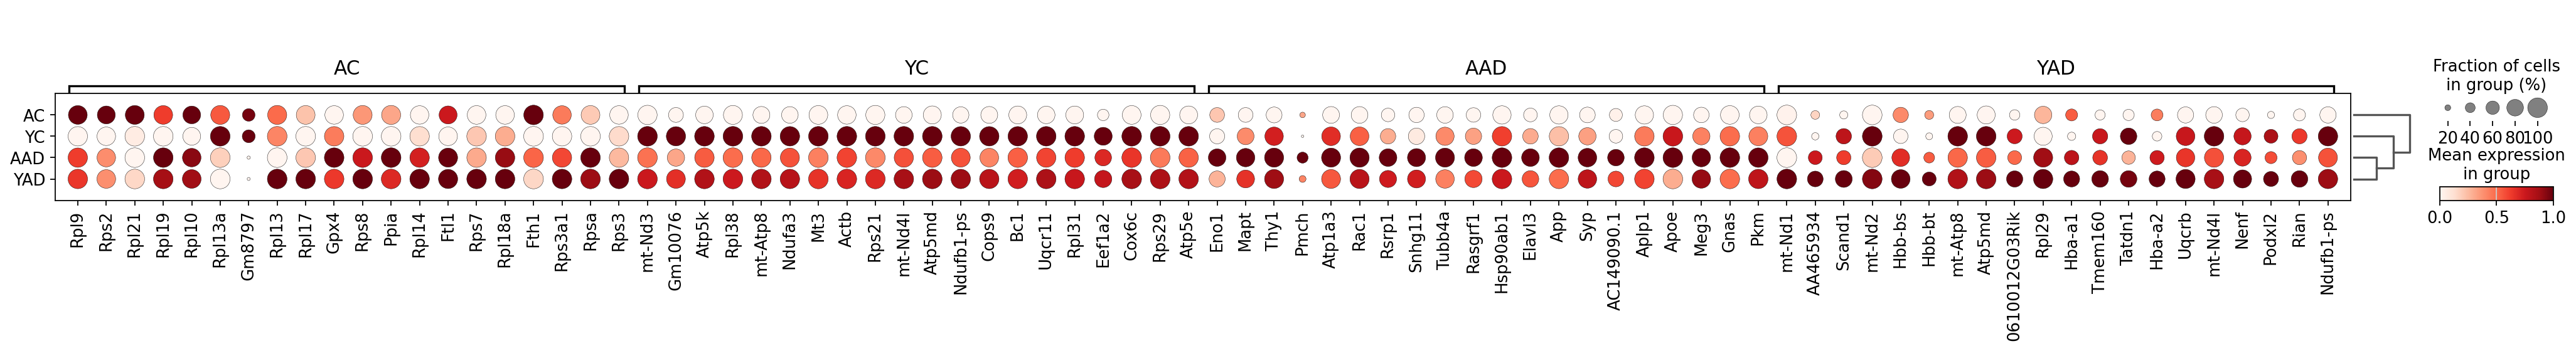

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd

# -------------------------
# Single-cell preprocessing
# -------------------------
sc_adata = adata  # replace path

# Basic QC metrics
sc.pp.calculate_qc_metrics(sc_adata, inplace=True)  # adds n_genes_by_counts, total_counts, pct_counts_{mt, rib}
# If mitochondrial genes are not auto-detected, set them:
# sc_adata.var['mt'] = sc_adata.var_names.str.upper().str.startswith('MT-')  # human style
# sc.pp.calculate_qc_metrics(sc_adata, qc_vars=['mt'], inplace=True)

# 1) Filter cells and genes
#sc.pp.filter_cells(sc_adata, min_genes=200)
#sc.pp.filter_genes(sc_adata, min_cells=3)

# 2) Compute percent mitochondrial (if not already present)
# Common pattern (human: MT- ; mouse: mt- or Mt-). Adjust to your organism.


# 3) Normalize total counts per cell (CPM / library size normalization)
sc.pp.normalize_total(sc_adata, target_sum=1)   # or 1e6 depending on preference

# 4) Log1p transform
sc.pp.log1p(sc_adata)

# 5) Save a raw layer (unscaled) for plotting and rank genes comparisons
sc_adata.raw = sc_adata   # safe copy, raw contains normalized log1p counts

# 6) Identify HVGs
sc.pp.highly_variable_genes(sc_adata, n_top_genes=2000)

# 7) Scale - center and scale (use adata.raw to preserve for plotting)
sc.pp.scale(sc_adata, max_value=10)   # caps extreme values; used for PCA and DE

# 8) PCA, neighbors, clustering
sc.tl.pca(sc_adata, svd_solver='arpack')
sc.pp.neighbors(sc_adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(sc_adata)
sc.tl.leiden(sc_adata, key_added='leiden')  # or sc.tl.louvain

# If you already have a grouping column (e.g., adata.obs['Group']), you can skip clustering.

# 9) Differential expression example (your code)
# Use groupby that you want (e.g. 'Group' or 'leiden' or cell type annotation)
groupby_key = "Group"  # change to your obs column
sc.tl.rank_genes_groups(sc_adata, groupby=groupby_key, method='wilcoxon')
sc.pl.rank_genes_groups_dotplot(sc_adata, groupby=groupby_key, standard_scale='var', n_genes=20)


In [31]:
# Access results
result = sc_adata.uns['rank_genes_groups']
groups = result['names'].dtype.names  # list of group names
top_genes_per_group = {}

for group in groups:
    # Get top 20 genes for this group
    top_genes = result['names'][group][:50]
    top_genes_per_group[group] = top_genes

# Convert to DataFrame for easy viewing
top_genes_df = pd.DataFrame(top_genes_per_group)
print(top_genes_df)


           AAD       AC            YAD         YC
0         Eno1     Rpl9         mt-Nd1     mt-Nd3
1         Mapt     Rps2       AA465934    Gm10076
2         Thy1    Rpl21         Scand1      Atp5k
3         Pmch    Rpl19         mt-Nd2      Rpl38
4       Atp1a3    Rpl10         Hbb-bs    mt-Atp8
5         Rac1   Rpl13a         Hbb-bt     Ndufa3
6        Rsrp1   Gm8797        mt-Atp8        Mt3
7       Snhg11    Rpl13         Atp5md       Actb
8       Tubb4a    Rpl17  0610012G03Rik      Rps21
9      Rasgrf1     Gpx4          Rpl29    mt-Nd4l
10    Hsp90ab1     Rps8         Hba-a1     Atp5md
11      Elavl3     Ppia        Tmem160  Ndufb1-ps
12         App    Rpl14         Tatdn1      Cops9
13         Syp     Ftl1         Hba-a2        Bc1
14  AC149090.1     Rps7          Uqcrb     Uqcr11
15       Aplp1   Rpl18a        mt-Nd4l      Rpl31
16        Apoe     Fth1           Nenf     Eef1a2
17        Meg3   Rps3a1         Podxl2      Cox6c
18        Gnas     Rpsa           Rian      Rps29
